In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
file_path = Path("../dataset/Online Retail.xlsx")

df = pd.read_excel(file_path)

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(5268)

In [8]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [9]:
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [10]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [11]:
# We need to verify how many invoices represent cancellations. :

df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [12]:
cancelled_invoices = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
]

cancelled_invoices.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96


In [13]:
cancelled_invoices.shape

(9288, 9)

In [14]:
df[df["Quantity"] < 0]["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

In [15]:
# Investigate zero/negative prices  :

df[df["UnitPrice"] <= 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,0.0
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.0
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,-0.0


In [16]:
df[df["UnitPrice"] <= 0][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
622,536414,22139,NaN,56,0.0,NaN
1970,536545,21134,NaN,1,0.0,NaN
1971,536546,22145,NaN,1,0.0,NaN
1972,536547,37509,NaN,1,0.0,NaN
1987,536549,85226A,NaN,1,0.0,NaN
1988,536550,85044,NaN,1,0.0,NaN
2024,536552,20950,NaN,1,0.0,NaN
2025,536553,37461,NaN,3,0.0,NaN
2026,536554,84670,NaN,23,0.0,NaN
2406,536589,21777,NaN,-10,0.0,NaN


In [17]:
# Investigate missing CustomerID  

df[df["CustomerID"].isna()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom,0.00
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom,2.51
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom,5.02
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom,3.40
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom,3.32


In [18]:
df.groupby(df["CustomerID"].isna())["Revenue"].sum()

CustomerID
False    8300065.814
True     1447682.120
Name: Revenue, dtype: float64

In [19]:
# Investigate missing Description: 

df[df["Description"].isna()].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,0.0
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.0
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,-0.0


In [20]:
df[df["Description"].isna()][
    ["InvoiceNo", "StockCode", "Quantity", "UnitPrice", "CustomerID"]
].head(20)

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID
622,536414,22139,56,0.0,NaN
1970,536545,21134,1,0.0,NaN
1971,536546,22145,1,0.0,NaN
1972,536547,37509,1,0.0,NaN
1987,536549,85226A,1,0.0,NaN
1988,536550,85044,1,0.0,NaN
2024,536552,20950,1,0.0,NaN
2025,536553,37461,3,0.0,NaN
2026,536554,84670,23,0.0,NaN
2406,536589,21777,-10,0.0,NaN


In [21]:
# Check duplicate records: 

df[df.duplicated(keep=False)].sort_values(
    by=["InvoiceNo", "StockCode"]
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,3.30
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom,1.65


In [22]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [23]:
# Negative quantity without a C invoice

negative_non_cancelled = df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
]

negative_non_cancelled.shape


(1336, 9)

In [24]:
negative_non_cancelled[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "UnitPrice", "CustomerID", "Country"]
].head(30)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,0.0,NaN,United Kingdom


In [25]:
# What are the zero-price records?

zero_price = df[df["UnitPrice"] == 0]

zero_price.shape

(2515, 9)

In [26]:
zero_price[
    ["InvoiceNo", "StockCode", "Description",
     "Quantity", "UnitPrice", "CustomerID", "Country"]
].head(30)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,0.0,NaN,United Kingdom


In [27]:
# Check the descriptions/categories of zero-price records

zero_price["Description"].value_counts(dropna=False).head(20)

Description
NaN                                1454
check                               159
?                                    47
damages                              45
damaged                              43
found                                25
sold as set on dotcom                20
adjustment                           16
Damaged                              14
Unsaleable, destroyed.                9
thrown away                           9
FRENCH BLUE METAL DOOR SIGN 1         9
FRENCH BLUE METAL DOOR SIGN 8         8
amazon                                8
Found                                 8
FRENCH BLUE METAL DOOR SIGN 4         7
Amazon                                7
FRENCH BLUE METAL DOOR SIGN 3         7
RECIPE BOX PANTRY YELLOW DESIGN       7
OWL DOORSTOP                          7
Name: count, dtype: int64

In [28]:
# exact duplicates after removing nothing

df_no_duplicates = df.drop_duplicates()

df_no_duplicates.shape

(536641, 9)

In [29]:
df_clean = df.copy()

In [30]:
df_clean = df_clean.drop_duplicates()

In [31]:
df_clean = df_clean[df_clean["Quantity"] > 0]

In [32]:
df_clean = df_clean[df_clean["UnitPrice"] > 0]

In [33]:
df_clean["Revenue"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

In [34]:
df_clean = df_clean.reset_index(drop=True)

In [35]:
df_clean.shape

(524878, 9)

In [36]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [37]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64

In [38]:
(df_clean["Quantity"] <= 0).sum()

np.int64(0)

In [39]:
(df_clean["UnitPrice"] <= 0).sum()

np.int64(0)

In [40]:
df_clean.duplicated().sum()

np.int64(0)

In [41]:
df_clean["CustomerID"].isna().sum()

np.int64(132186)

In [42]:
df_clean["Description"].isna().sum()

np.int64(0)

In [43]:
cleaning_summary = {
    "Original Rows": len(df),
    "Cleaned Rows": len(df_clean),
    "Rows Removed": len(df) - len(df_clean),
    "Duplicate Rows Removed": df.duplicated().sum(),
    "Negative Quantity Removed": (df["Quantity"] < 0).sum(),
    "Non-Positive Price Removed": (df["UnitPrice"] <= 0).sum(),
    "Missing CustomerID After Cleaning": df_clean["CustomerID"].isna().sum()
}

cleaning_summary

{'Original Rows': 541909,
 'Cleaned Rows': 524878,
 'Rows Removed': 17031,
 'Duplicate Rows Removed': np.int64(5268),
 'Negative Quantity Removed': np.int64(10624),
 'Non-Positive Price Removed': np.int64(2517),
 'Missing CustomerID After Cleaning': np.int64(132186)}

In [44]:
retention_rate = (len(df_clean) / len(df)) * 100

print(f"Data Retention Rate: {retention_rate:.2f}%")

Data Retention Rate: 96.86%


In [45]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,524878.000000,524878,524878.000000,392692.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,15287.843865,20.275399
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,3.900000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,9.920000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,156.280031,NaN,36.093028,1713.539549,271.693566


In [46]:
df_clean[["Quantity", "UnitPrice", "Revenue"]].describe()

,Quantity,UnitPrice,Revenue
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


In [47]:
df_clean["Revenue"].sum()

np.float64(10642110.804000001)

In [48]:
print("Start Date:", df_clean["InvoiceDate"].min())
print("End Date:", df_clean["InvoiceDate"].max())

Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00


In [49]:
print("Number of Days:",
      (df_clean["InvoiceDate"].max() - df_clean["InvoiceDate"].min()).days)

Number of Days: 373


In [50]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["Month_Name"] = df_clean["InvoiceDate"].dt.month_name()
df_clean["Day"] = df_clean["InvoiceDate"].dt.day
df_clean["Day_Name"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

In [51]:
df_clean["Year_Month"] = (
    df_clean["InvoiceDate"].dt.to_period("M").astype(str)
)

In [52]:
df_clean[
    ["InvoiceDate", "Year", "Month", "Month_Name",
     "Day", "Day_Name", "Hour", "Year_Month"]
].head()

,InvoiceDate,Year,Month,Month_Name,Day,Day_Name,Hour,Year_Month
0,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8,2010-12
1,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8,2010-12
2,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8,2010-12
3,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8,2010-12
4,2010-12-01 08:26:00,2010,12,December,1,Wednesday,8,2010-12


In [53]:
df_clean["StockCode"].nunique()

3922

In [54]:
df_clean["InvoiceNo"].nunique()

19960

In [55]:
df_clean["CustomerID"].nunique()

4338

In [56]:
df_clean["Country"].nunique()

38

In [57]:
top_products_quantity = (
    df_clean.groupby(
        ["StockCode", "Description"],
        dropna=False
    )["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           80995
23166      MEDIUM CERAMIC TOP STORAGE JAR        78033
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
85099B     JUMBO BAG RED RETROSPOT               48371
85123A     WHITE HANGING HEART T-LIGHT HOLDER    37580
22197      POPCORN HOLDER                        36749
21212      PACK OF 72 RETROSPOT CAKE CASES       36396
84879      ASSORTED COLOUR BIRD ORNAMENT         36362
23084      RABBIT NIGHT LIGHT                    30739
22492      MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [58]:
top_products_revenue = (
    df_clean.groupby(
        ["StockCode", "Description"],
        dropna=False
    )["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

StockCode  Description                       
DOT        DOTCOM POSTAGE                        206248.77
22423      REGENCY CAKESTAND 3 TIER              174156.54
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
85123A     WHITE HANGING HEART T-LIGHT HOLDER    104284.24
47566      PARTY BUNTING                          99445.23
85099B     JUMBO BAG RED RETROSPOT                94159.81
23166      MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POST       POSTAGE                                78101.88
M          Manual                                 77750.27
23084      RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [59]:
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [60]:
country_transactions = (
    df_clean.groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

country_transactions

Country
United Kingdom    18019
Germany             457
France              392
EIRE                288
Belgium              98
Netherlands          94
Spain                90
Portugal             58
Australia            57
Switzerland          54
Name: InvoiceNo, dtype: int64

In [61]:
output_path = Path("../dataset/online_retail_clean.csv")

df_clean.to_csv(
    output_path,
    index=False
)

print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: ..\dataset\online_retail_clean.csv


In [62]:
cleaning_summary

{'Original Rows': 541909,
 'Cleaned Rows': 524878,
 'Rows Removed': 17031,
 'Duplicate Rows Removed': np.int64(5268),
 'Negative Quantity Removed': np.int64(10624),
 'Non-Positive Price Removed': np.int64(2517),
 'Missing CustomerID After Cleaning': np.int64(132186)}

In [63]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Year,Month,Day,Hour
count,524878.000000,524878,524878.000000,392692.000000,524878.000000,524878.000000,524878.000000,524878.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049088,3.922573,15287.843865,20.275399,2010.921904,7.552237,15.022472,13.073991
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,2010.000000,1.000000,1.000000,6.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,3.900000,2011.000000,5.000000,7.000000,11.000000
50%,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,9.920000,2011.000000,8.000000,15.000000,13.000000
75%,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,17.700000,2011.000000,11.000000,22.000000,15.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,156.280031,NaN,36.093028,1713.539549,271.693566,0.268323,3.508164,8.660738,2.442994


In [64]:
print("Start Date:", df_clean["InvoiceDate"].min())
print("End Date:", df_clean["InvoiceDate"].max())

Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00


In [65]:
df_clean["Revenue"].sum()

np.float64(10642110.804000001)

In [66]:
df_clean["Week"] = df_clean["InvoiceDate"].dt.isocalendar().week

In [67]:
df_clean["Quarter"] = (
    "Q" + df_clean["InvoiceDate"].dt.quarter.astype(str)
)

In [68]:
df_clean["Day_of_Week"] = df_clean["InvoiceDate"].dt.dayofweek

In [69]:
df_clean["Revenue_Rounded"] = df_clean["Revenue"].round(2)

In [70]:
monthly_revenue = (
    df_clean.groupby("Year_Month")["Revenue"]
    .sum()
    .sort_index()
)

monthly_revenue

Year_Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Name: Revenue, dtype: float64

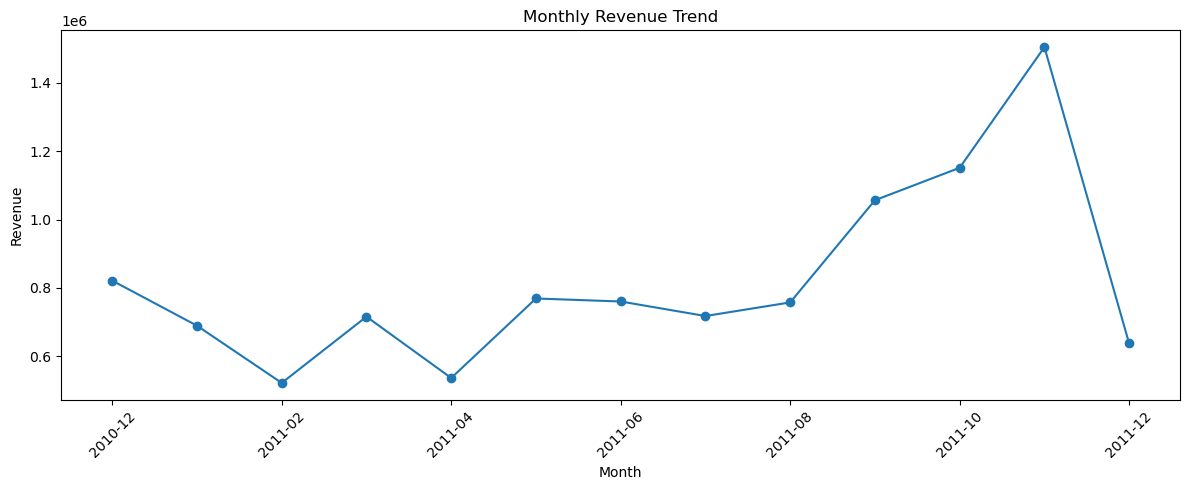

In [71]:
monthly_revenue.plot(
    figsize=(12, 5),
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
monthly_orders = (
    df_clean.groupby("Year_Month")["InvoiceNo"]
    .nunique()
    .sort_index()
)

monthly_orders

Year_Month
2010-12    1559
2011-01    1086
2011-02    1100
2011-03    1454
2011-04    1246
2011-05    1681
2011-06    1533
2011-07    1475
2011-08    1361
2011-09    1837
2011-10    2040
2011-11    2769
2011-12     819
Name: InvoiceNo, dtype: int64

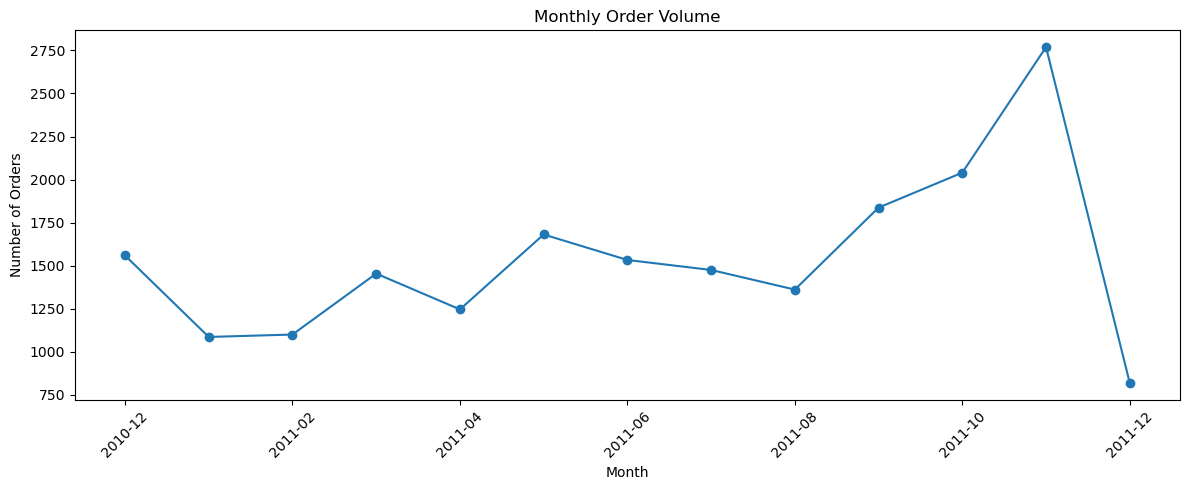

In [73]:
monthly_orders.plot(
    figsize=(12, 5),
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
# AOV = Revenue / Number of Unique Orders

total_revenue = df_clean["Revenue"].sum()
total_orders = df_clean["InvoiceNo"].nunique()

aov = total_revenue / total_orders

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: £{aov:,.2f}")

Total Revenue: £10,642,110.80
Total Orders: 19,960
Average Order Value: £533.17


In [75]:
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

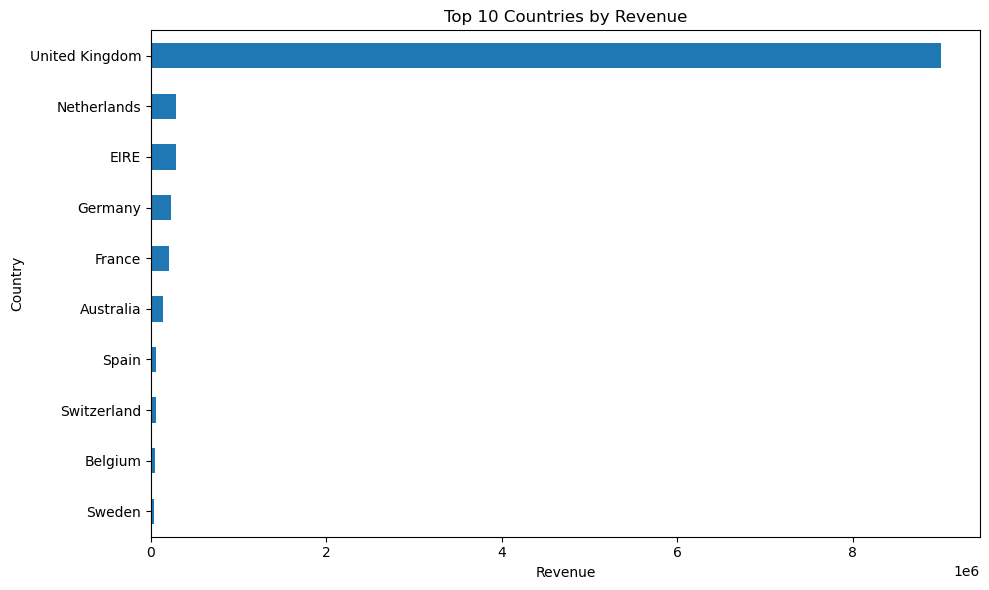

In [76]:
country_revenue.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [77]:
top_products_quantity = (
    df_clean.groupby(["StockCode", "Description"])["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           80995
23166      MEDIUM CERAMIC TOP STORAGE JAR        78033
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
85099B     JUMBO BAG RED RETROSPOT               48371
85123A     WHITE HANGING HEART T-LIGHT HOLDER    37580
22197      POPCORN HOLDER                        36749
21212      PACK OF 72 RETROSPOT CAKE CASES       36396
84879      ASSORTED COLOUR BIRD ORNAMENT         36362
23084      RABBIT NIGHT LIGHT                    30739
22492      MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [78]:
top_products_revenue = (
    df_clean.groupby(["StockCode", "Description"])["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

StockCode  Description                       
DOT        DOTCOM POSTAGE                        206248.77
22423      REGENCY CAKESTAND 3 TIER              174156.54
23843      PAPER CRAFT , LITTLE BIRDIE           168469.60
85123A     WHITE HANGING HEART T-LIGHT HOLDER    104284.24
47566      PARTY BUNTING                          99445.23
85099B     JUMBO BAG RED RETROSPOT                94159.81
23166      MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POST       POSTAGE                                78101.88
M          Manual                                 77750.27
23084      RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [79]:
df_customer = df_clean.dropna(
    subset=["CustomerID"]
).copy()

In [80]:
customer_count = df_customer["CustomerID"].nunique()

print(f"Unique Customers: {customer_count:,}")

Unique Customers: 4,338


In [81]:
output_path = Path("../dataset/online_retail_clean.csv")

df_clean.to_csv(output_path, index=False)

print(f"Saved: {output_path}")

Saved: ..\dataset\online_retail_clean.csv


In [82]:
import os

os.path.exists(output_path)

True

In [83]:
# Time & Sales Pattern Analysis

In [84]:
daily_revenue = (
    df_clean.groupby(df_clean["InvoiceDate"].dt.date)["Revenue"]
    .sum()
)

daily_revenue.head()

InvoiceDate
2010-12-01    58776.79
2010-12-02    47629.42
2010-12-03    46898.63
2010-12-05    31364.63
2010-12-06    54624.15
Name: Revenue, dtype: float64

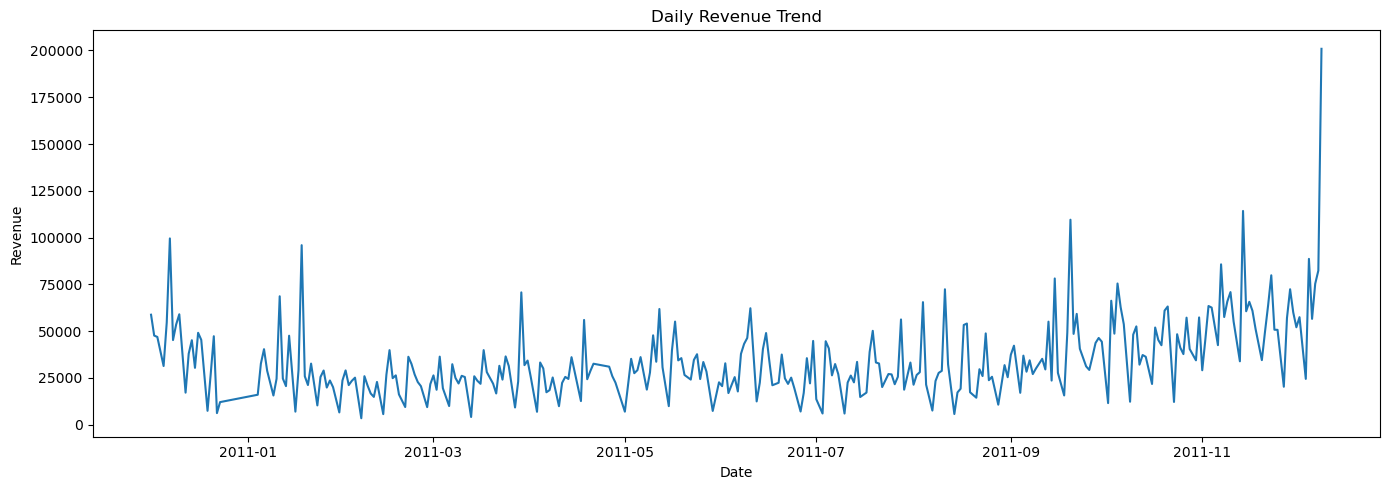

In [85]:
plt.figure(figsize=(14, 5))

daily_revenue.plot()

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [87]:
weekday_revenue = (
    df_clean.groupby("Day_Name")["Revenue"]
    .sum()
)

In [88]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_revenue = weekday_revenue.reindex(day_order)

weekday_revenue

Day_Name
Monday       1775782.071
Tuesday      2175700.511
Wednesday    1847074.380
Thursday     2199292.570
Friday       1837470.491
Saturday             NaN
Sunday        806790.781
Name: Revenue, dtype: float64

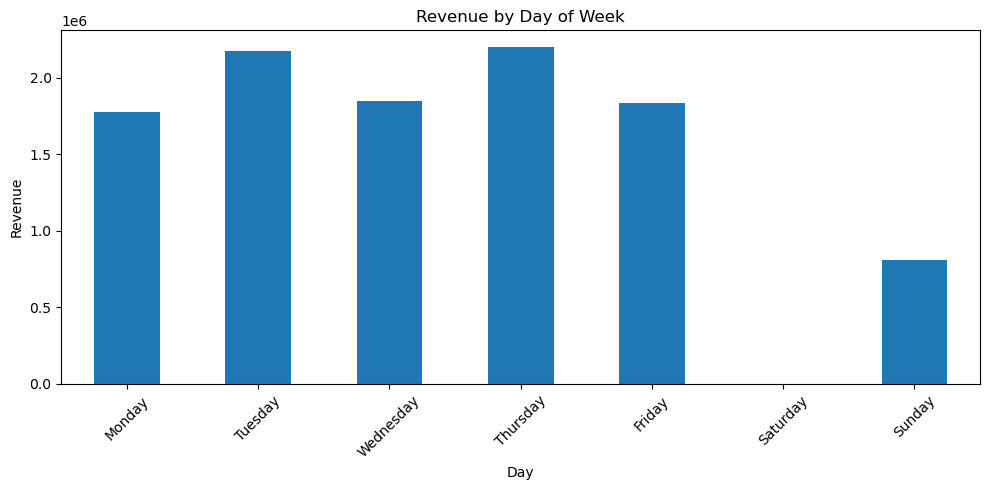

In [89]:
plt.figure(figsize=(10, 5))

weekday_revenue.plot(kind="bar")

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [90]:
hourly_revenue = (
    df_clean.groupby("Hour")["Revenue"]
    .sum()
    .sort_index()
)

hourly_revenue

Hour
6           4.250
7       31059.210
8      283750.680
9      990054.991
10    1444814.771
11    1236573.290
12    1439324.660
13    1261195.200
14    1177907.521
15    1350333.310
16     752487.960
17     460963.921
18     144603.610
19      50204.950
20      18832.480
Name: Revenue, dtype: float64

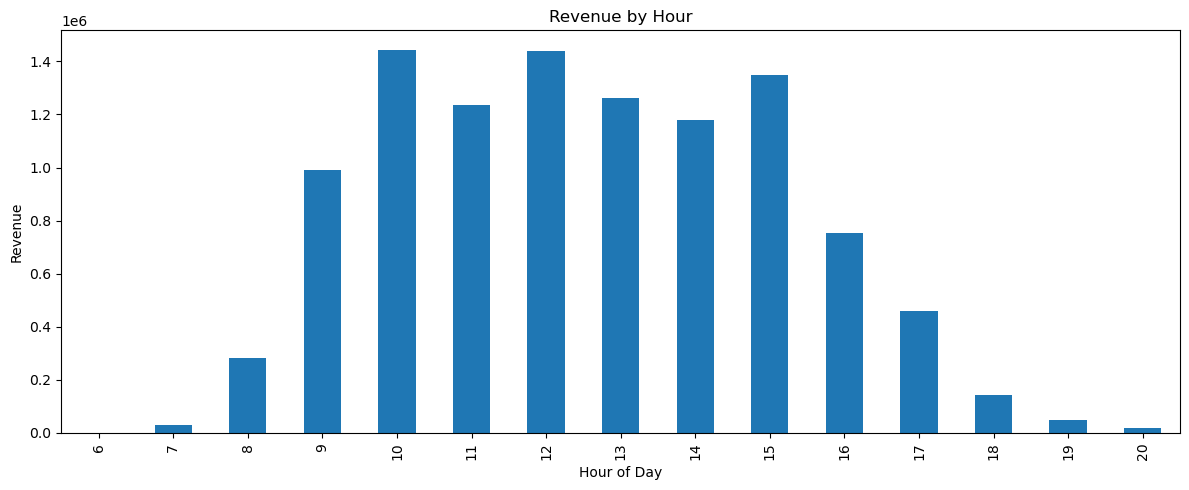

In [91]:
plt.figure(figsize=(12, 5))

hourly_revenue.plot(kind="bar")

plt.title("Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [92]:
# Customer Analysis

In [93]:
df_customer["CustomerID"] = (
    df_customer["CustomerID"]
    .astype(int)
    .astype(str)
)

In [94]:
df_customer["CustomerID"].head()

0    17850
1    17850
2    17850
3    17850
4    17850
Name: CustomerID, dtype: object

In [95]:
customer_revenue = (
    df_customer.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: Revenue, dtype: float64

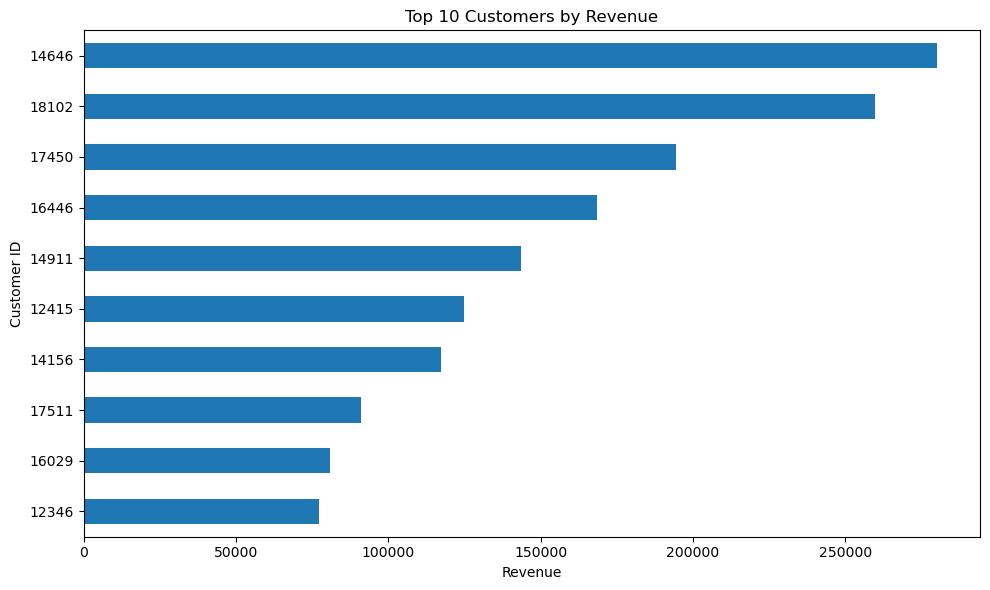

In [96]:
plt.figure(figsize=(10, 6))

customer_revenue.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

In [97]:
customer_orders = (
    df_customer.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

customer_orders.head(10)

CustomerID
12748    209
14911    201
17841    124
13089     97
14606     93
15311     91
12971     86
14646     73
16029     63
13408     62
Name: InvoiceNo, dtype: int64

In [98]:
customer_summary = (
    df_customer.groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
)

In [99]:
customer_summary["AOV"] = (
    customer_summary["Total_Revenue"] /
    customer_summary["Total_Orders"]
)

In [100]:
customer_summary.head()

,Total_Revenue,Total_Orders,Total_Quantity,AOV
CustomerID,,,,
12346,77183.60,1,74215,77183.600000
12347,4310.00,7,2458,615.714286
12348,1797.24,4,2341,449.310000
12349,1757.55,1,631,1757.550000
12350,334.40,1,197,334.400000


In [101]:
customer_summary.sort_values(
    "Total_Revenue",
    ascending=False
).head(10)

,Total_Revenue,Total_Orders,Total_Quantity,AOV
CustomerID,,,,
14646,280206.02,73,196915,3838.438630
18102,259657.30,60,64124,4327.621667
17450,194390.79,46,69973,4225.886739
16446,168472.50,2,80997,84236.250000
14911,143711.17,201,80240,714.980945
12415,124914.53,21,77374,5948.310952
14156,117210.08,55,57768,2131.092364
17511,91062.38,31,64549,2937.496129
16029,80850.84,63,40108,1283.346667


In [102]:
avg_orders_per_customer = customer_summary["Total_Orders"].mean()

print(
    f"Average Orders per Customer: "
    f"{avg_orders_per_customer:.2f}"
)

Average Orders per Customer: 4.27


In [103]:
print(
    f"Median Orders per Customer: "
    f"{customer_summary['Total_Orders'].median():.0f}"
)

Median Orders per Customer: 2


In [104]:
# Country Customer Analysis

In [105]:
country_customers = (
    df_customer.groupby("Country")["CustomerID"]
    .nunique()
    .sort_values(ascending=False)
)

country_customers.head(10)

Country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: CustomerID, dtype: int64

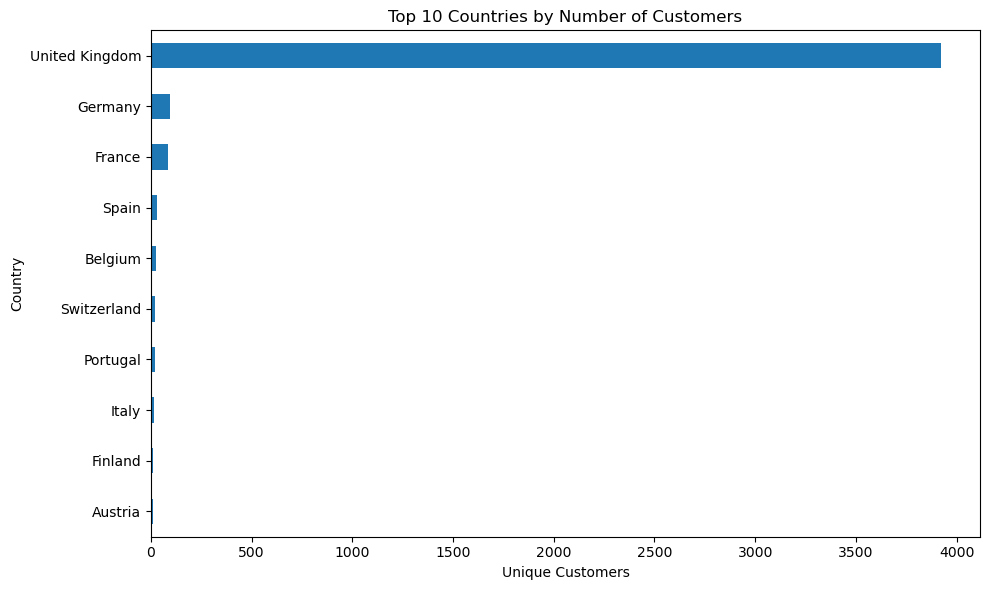

In [106]:
plt.figure(figsize=(10, 6))

country_customers.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Number of Customers")
plt.xlabel("Unique Customers")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [107]:
country_analysis = (
    df_customer.groupby("Country")
    .agg(
        Revenue=("Revenue", "sum"),
        Customers=("CustomerID", "nunique"),
        Orders=("InvoiceNo", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

country_analysis.head(10)

,Revenue,Customers,Orders
Country,,,
United Kingdom,7285024.644,3920,16646
Netherlands,285446.340,9,94
EIRE,265262.460,3,260
Germany,228678.400,94,457
France,208934.310,87,389
Australia,138453.810,9,57
Spain,61558.560,30,90
Switzerland,56443.950,21,51
Belgium,41196.340,25,98


In [108]:
country_analysis["Revenue_per_Customer"] = (
    country_analysis["Revenue"] /
    country_analysis["Customers"]
)

In [109]:
country_analysis.head(10)

,Revenue,Customers,Orders,Revenue_per_Customer
Country,,,,
United Kingdom,7285024.644,3920,16646,1858.424654
Netherlands,285446.340,9,94,31716.260000
EIRE,265262.460,3,260,88420.820000
Germany,228678.400,94,457,2432.748936
France,208934.310,87,389,2401.543793
Australia,138453.810,9,57,15383.756667
Spain,61558.560,30,90,2051.952000
Switzerland,56443.950,21,51,2687.807143
Belgium,41196.340,25,98,1647.853600


In [110]:
# Building the RFM Dataset

In [111]:
rfm_reference_date = (
    df_customer["InvoiceDate"].max().normalize()
    + pd.Timedelta(days=1)
)

rfm_reference_date

Timestamp('2011-12-10 00:00:00')

In [112]:
rfm = (
    df_customer.groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (
                rfm_reference_date - x.max().normalize()
            ).days
        ),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
)

In [113]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,3,7,4310.00
12348,76,4,1797.24
12349,19,1,1757.55
12350,311,1,334.40


In [114]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,93.059474,4.272015,2048.688081
std,100.012264,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.750000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [115]:
rfm.to_csv(
    "../dataset/customer_rfm.csv"
)

In [116]:
Path("../dataset/customer_rfm.csv").exists()

True